In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
file_paths = sorted(glob.glob("csv_results/gender_sample_fraction_large_*.csv"))
all_dfs = []

for path in file_paths:
    df = pd.read_csv(path)
    df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
    all_dfs.append(df)

# Объединяем в один DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

In [3]:
len(df_all)

2850

In [4]:
print(df_all)

      Unnamed: 0  batch_size  learning_rate  split_count  cnt_min  cnt_max  \
0              0          16          0.001            3       10      100   
1              1          16          0.001            3       10      100   
2              2          16          0.001            3       10      100   
3              3          16          0.001            3       10      100   
4              4          16          0.001            3       10      100   
...          ...         ...            ...          ...      ...      ...   
2845         565          64          0.001            3       10      100   
2846         566          64          0.001            3       10      100   
2847         567          64          0.001            3       10      100   
2848         568          64          0.001            3       10      100   
2849         569          64          0.001            3       10      100   

      embedding_dim  category_embedding_dim  hidden_size  mcc_c

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df_all[["metric_ripser_sum_H0", "metric_ripser_sum_H1"]])
weighted_sum = np.mean(scaled, axis=1)
df_all['ripser_weighted'] = weighted_sum

In [ ]:
#combinations
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] \
+ ['ripser_weighted', 'recall_topk']
all_metric_columns = []
for metric1 in metric_columns:
    for metric2 in metric_columns:
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(df_all[[metric1, metric2]])
        weighted_sum = np.mean(scaled, axis=1)
        all_metric_columns.append(metric1 + "_" + metric2 + '_weighted')
        all_metric_columns.append(metric1 + "_" + metric2 + '_prod')
        df_all[metric1 + "_" + metric2 + '_weighted'] = weighted_sum
        df_all[metric1 + "_" + metric2 + '_prod'] = scaled[:,0] * scaled[:,1]

all_metric_columns += metric_columns

In [26]:
df_all = df_all.set_index('checkpoint')

In [42]:
corr_records = []

# Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))

        if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
            corr = sub[metric].corr(sub['roc_auc'])
            corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": sign * corr
            })

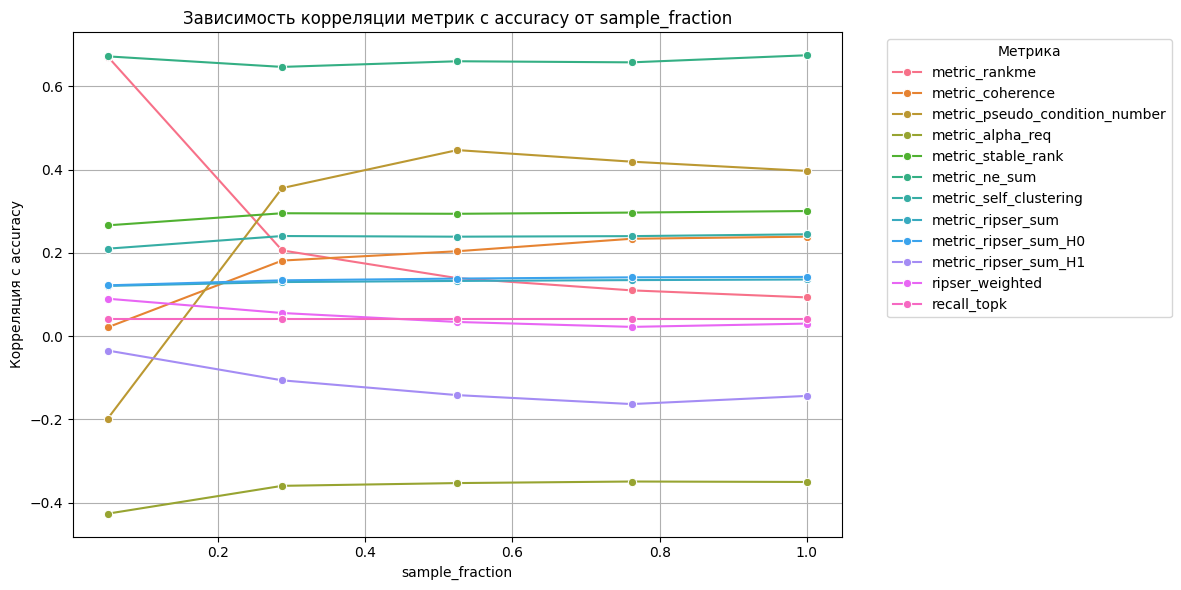

In [43]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [44]:
print(corr_df)

    sample_fraction                          metric  correlation
0             0.050                   metric_rankme     0.671351
1             0.050                metric_coherence     0.021293
2             0.050  metric_pseudo_condition_number    -0.197846
3             0.050                metric_alpha_req    -0.426144
4             0.050              metric_stable_rank     0.266160
5             0.050                   metric_ne_sum     0.671841
6             0.050          metric_self_clustering     0.210137
7             0.050               metric_ripser_sum     0.120678
8             0.050            metric_ripser_sum_H0     0.122091
9             0.050            metric_ripser_sum_H1    -0.034430
10            0.050                 ripser_weighted     0.089940
11            0.050                     recall_topk     0.041858
12            0.287                   metric_rankme     0.205922
13            0.287                metric_coherence     0.181563
14            0.287  metr

In [45]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                     0.662112
metric_stable_rank                0.290504
metric_pseudo_condition_number    0.284072
metric_rankme                     0.243950
metric_self_clustering            0.234892
metric_coherence                  0.175957
metric_ripser_sum_H0              0.135607
metric_ripser_sum                 0.130806
ripser_weighted                   0.046466
recall_topk                       0.041858
metric_ripser_sum_H1             -0.117678
metric_alpha_req                 -0.367431
Name: correlation, dtype: float64

In [46]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                     0.674534
metric_pseudo_condition_number    0.396771
metric_stable_rank                0.300488
metric_self_clustering            0.244685
metric_coherence                  0.238996
metric_ripser_sum_H0              0.142303
metric_ripser_sum                 0.136109
metric_rankme                     0.093117
recall_topk                       0.041858
ripser_weighted                   0.030248
metric_ripser_sum_H1             -0.143399
metric_alpha_req                 -0.350025
Name: correlation, dtype: float64

In [47]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                     0.659196
metric_rankme                     0.438636
metric_stable_rank                0.280676
metric_self_clustering            0.225309
metric_ripser_sum_H0              0.128083
metric_ripser_sum                 0.125320
metric_coherence                  0.101428
metric_pseudo_condition_number    0.078880
ripser_weighted                   0.072803
recall_topk                       0.041858
metric_ripser_sum_H1             -0.070225
metric_alpha_req                 -0.392739
Name: correlation, dtype: float64

# Overall Spearmann Corr

In [48]:
from scipy.stats import spearmanr


spear_corr_records = []

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        if sub[metric].nunique() > 1 and sub['accuracy'].nunique() > 1:
            corr, _ = spearmanr(sub[metric], sub['roc_auc'])
            spear_corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": sign * corr
            })
            


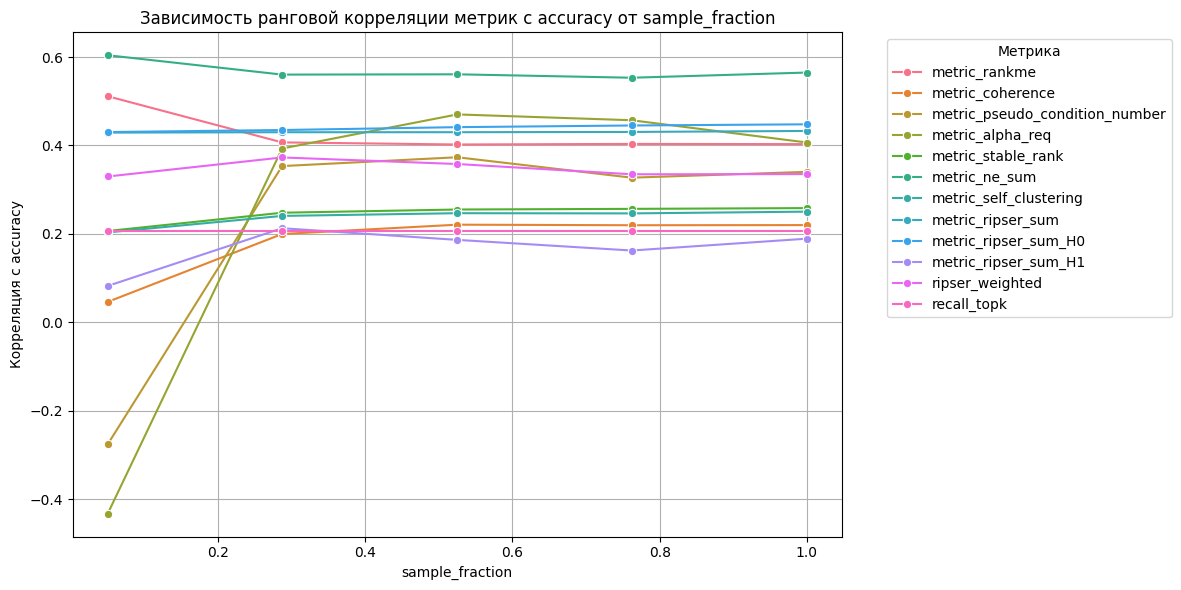

In [49]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [50]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.5648899706417037,
 'metric_ripser_sum_H0': 0.447795763646565,
 'metric_ripser_sum': 0.43279642728430046,
 'metric_alpha_req': 0.4066601719360017,
 'metric_rankme': 0.4029909151403321,
 'metric_pseudo_condition_number': 0.3402500236324109,
 'ripser_weighted': 0.3352406546778633,
 'metric_stable_rank': 0.2582918776777793,
 'metric_self_clustering': 0.25027257251221147,
 'metric_coherence': 0.21984721827847276,
 'recall_topk': 0.20622387489208185,
 'metric_ripser_sum_H1': 0.18913519374773052}

In [51]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.5686368275971679,
 'metric_ripser_sum_H0': 0.43989380432108155,
 'metric_ripser_sum': 0.4304506237289788,
 'metric_rankme': 0.42535178898255566,
 'ripser_weighted': 0.3461296961396833,
 'metric_alpha_req': 0.2588225178127283,
 'metric_stable_rank': 0.2448398910894752,
 'metric_self_clustering': 0.23746259099872039,
 'metric_pseudo_condition_number': 0.22363249556025228,
 'recall_topk': 0.20622387489208185,
 'metric_coherence': 0.18121297615551107,
 'metric_ripser_sum_H1': 0.16658514043596184}

In [52]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.582120163765167,
 'metric_rankme': 0.45907726925885867,
 'metric_ripser_sum_H0': 0.43257644583052013,
 'metric_ripser_sum': 0.42948244937042124,
 'ripser_weighted': 0.35132270997981063,
 'metric_stable_rank': 0.2271280309898765,
 'metric_self_clustering': 0.22197954616286775,
 'recall_topk': 0.20622387489208185,
 'metric_ripser_sum_H1': 0.1475200106948846,
 'metric_coherence': 0.12295171003184004,
 'metric_pseudo_condition_number': 0.03874269189259272,
 'metric_alpha_req': -0.019871636333142123}

# Correlation for best checkpoint choice

In [53]:
from scipy.stats import spearmanr


spear_corr_records = []
df_all['checkpoint'] = df_all.index.values
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr, _ = spearmanr(check_data[metric], check_data['roc_auc'])
                spear_corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
            


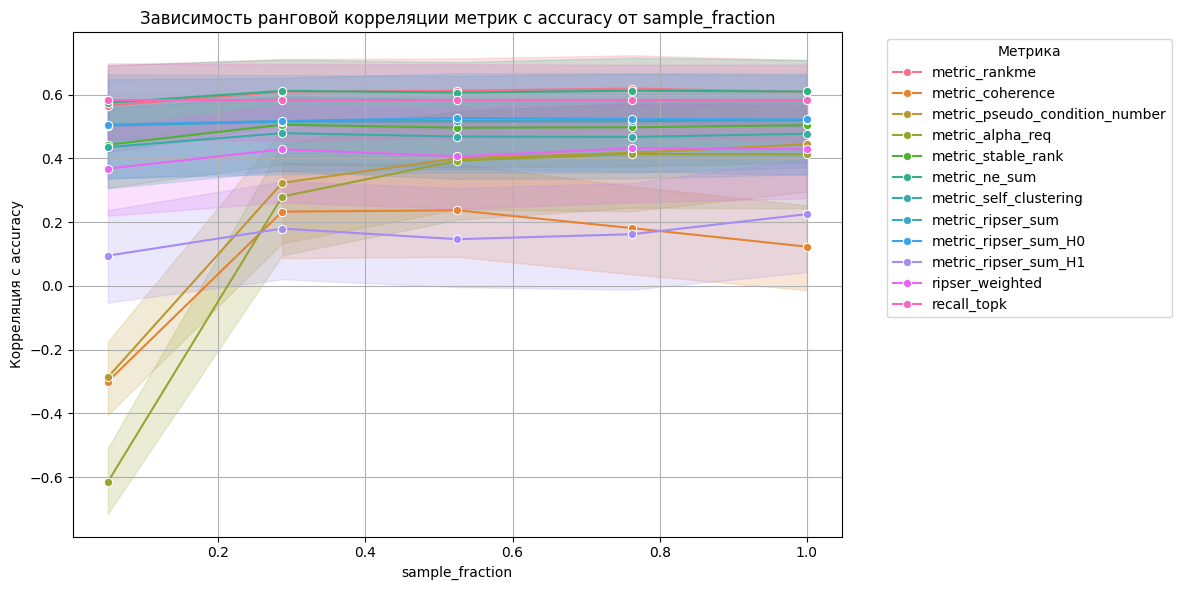

In [54]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [55]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.6096779601252454,
 'metric_rankme': 0.6082473956161695,
 'recall_topk': 0.5845188049426021,
 'metric_ripser_sum_H0': 0.5220662033087687,
 'metric_ripser_sum': 0.5197003835897275,
 'metric_stable_rank': 0.5039851028844595,
 'metric_self_clustering': 0.4771709022883898,
 'metric_pseudo_condition_number': 0.44408723322000243,
 'ripser_weighted': 0.4286704904404554,
 'metric_alpha_req': 0.4123100347835765,
 'metric_ripser_sum_H1': 0.22495748606173738,
 'metric_coherence': 0.12288805913752247}

In [56]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.6028336533366195,
 'metric_rankme': 0.602717997908274,
 'recall_topk': 0.5845188049426021,
 'metric_ripser_sum_H0': 0.5188510420800723,
 'metric_ripser_sum': 0.5141141547079113,
 'metric_stable_rank': 0.48921569099315215,
 'metric_self_clustering': 0.46534277996688184,
 'ripser_weighted': 0.4124943658164674,
 'metric_pseudo_condition_number': 0.2553679580405978,
 'metric_coherence': 0.18786631197018502,
 'metric_alpha_req': 0.1768251990992857,
 'metric_ripser_sum_H1': 0.16155159148273918}

In [57]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.5929426213833442,
 'metric_rankme': 0.5871895143392742,
 'recall_topk': 0.5845188049426021,
 'metric_ripser_sum_H0': 0.5113214934744629,
 'metric_ripser_sum': 0.5088441229423357,
 'metric_stable_rank': 0.4742254486640311,
 'metric_self_clustering': 0.4570236618196629,
 'ripser_weighted': 0.39810861887880145,
 'metric_coherence': 0.21307066934294203,
 'metric_ripser_sum_H1': 0.1371998402477302,
 'metric_pseudo_condition_number': 0.0077190889295543205,
 'metric_alpha_req': -0.16731427253669615}

# Linear correlation of epoch choice

In [59]:

corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric].corr(check_data['roc_auc'])
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
     

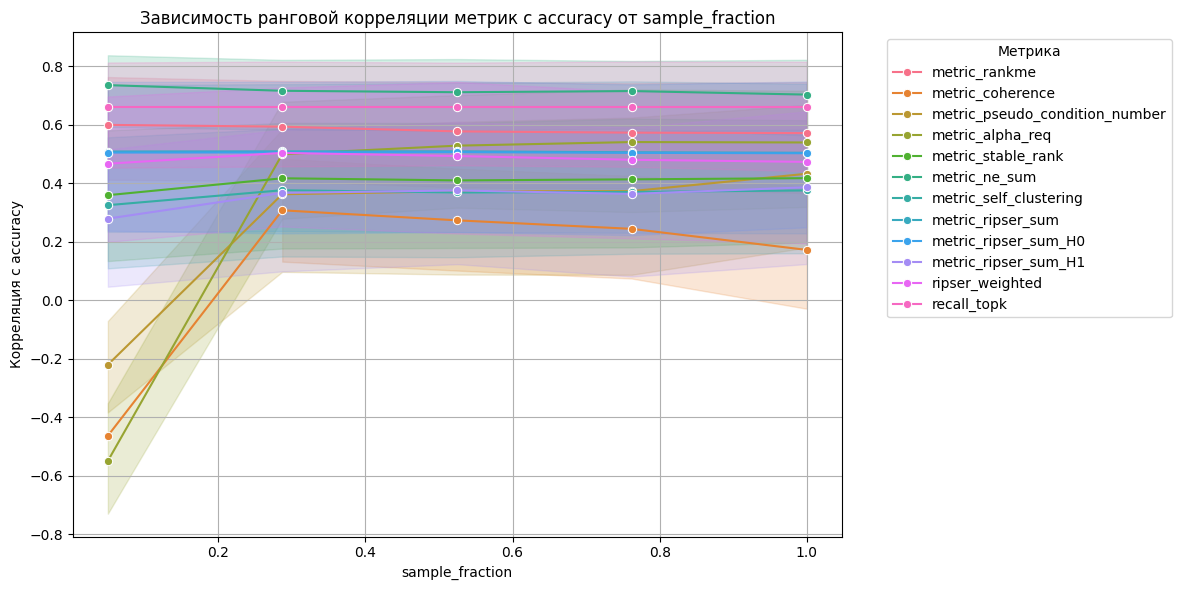

In [60]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [61]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                     0.702447
recall_topk                       0.658483
metric_rankme                     0.570966
metric_alpha_req                  0.538979
metric_ripser_sum                 0.503734
metric_ripser_sum_H0              0.502186
ripser_weighted                   0.472628
metric_pseudo_condition_number    0.432133
metric_stable_rank                0.417017
metric_ripser_sum_H1              0.385988
metric_self_clustering            0.375069
metric_coherence                  0.171971
Name: correlation, dtype: float64

In [62]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                     0.725188
recall_topk                       0.658483
metric_rankme                     0.595970
metric_ripser_sum                 0.508280
metric_ripser_sum_H0              0.504743
ripser_weighted                   0.484887
metric_stable_rank                0.387778
metric_self_clustering            0.350286
metric_ripser_sum_H1              0.322805
metric_coherence                  0.261930
metric_pseudo_condition_number    0.070941
metric_alpha_req                 -0.025030
Name: correlation, dtype: float64

# Score of best epoch

In [63]:
corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                pick = check_data['roc_auc'].values[
                    np.argmax(sign * check_data[metric].values)]
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "auc": pick
                })

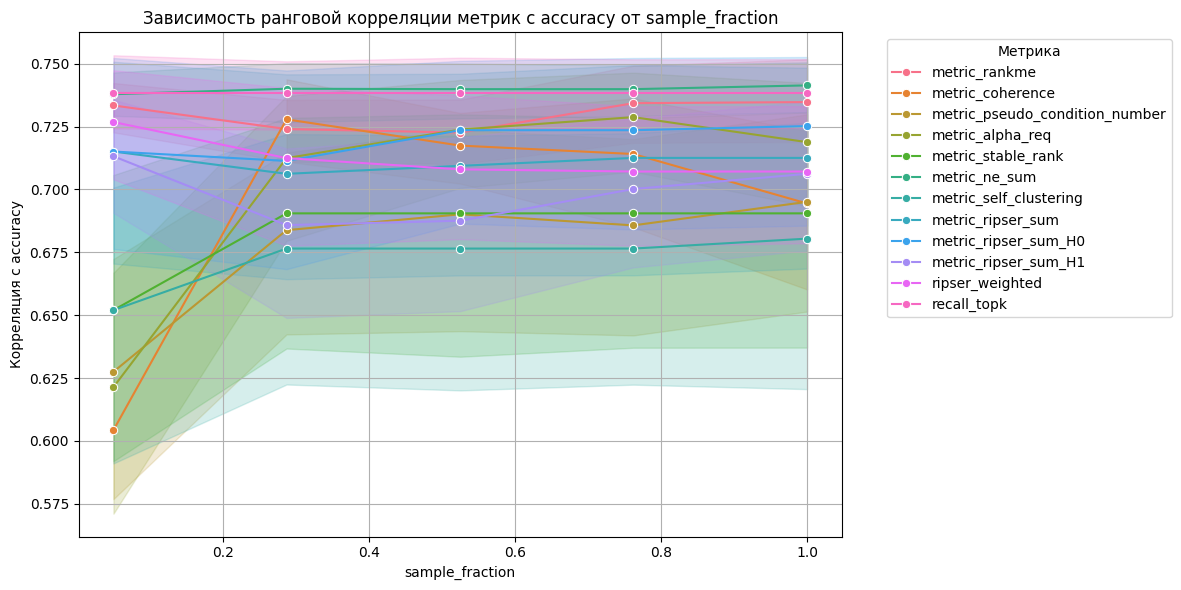

In [64]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [65]:
corr_df = pd.DataFrame(corr_records)
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7398088888888888,
 'recall_topk': 0.7384555555555555,
 'metric_rankme': 0.7298155555555557,
 'metric_ripser_sum_H0': 0.7197422222222222,
 'ripser_weighted': 0.7122977777777777,
 'metric_ripser_sum': 0.7111533333333333,
 'metric_coherence': 0.7098085714285715,
 'metric_alpha_req': 0.7010444444444445,
 'metric_ripser_sum_H1': 0.6985933333333333,
 'metric_stable_rank': 0.6827911111111111,
 'metric_pseudo_condition_number': 0.6764422222222223,
 'metric_self_clustering': 0.67238}

In [66]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7413777777777777,
 'recall_topk': 0.7384555555555555,
 'metric_rankme': 0.7347333333333332,
 'metric_ripser_sum_H0': 0.7251888888888889,
 'metric_alpha_req': 0.7188111111111111,
 'metric_ripser_sum': 0.7125444444444444,
 'ripser_weighted': 0.7071222222222222,
 'metric_ripser_sum_H1': 0.7062222222222222,
 'metric_pseudo_condition_number': 0.6950777777777778,
 'metric_coherence': 0.6944111111111111,
 'metric_stable_rank': 0.6904888888888888,
 'metric_self_clustering': 0.6804333333333333}

In [67]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7389555555555556,
 'recall_topk': 0.7384555555555555,
 'metric_rankme': 0.7287055555555555,
 'ripser_weighted': 0.7196277777777778,
 'metric_coherence': 0.7141444444444445,
 'metric_ripser_sum_H0': 0.7132055555555555,
 'metric_ripser_sum': 0.7106444444444444,
 'metric_ripser_sum_H1': 0.6995055555555555,
 'metric_stable_rank': 0.6712444444444444,
 'metric_alpha_req': 0.6669222222222222,
 'metric_self_clustering': 0.6642444444444444,
 'metric_pseudo_condition_number': 0.6556555555555555}

In [47]:
from collections import defaultdict
comb_w = defaultdict(dict)
comb_prod = defaultdict(dict)

for metric in metric_columns:
    for i in range(mean_corr.shape[0]):
        if metric in mean_corr.index.values[i]:
            if 'prod' in mean_corr.index.values[i]:
                comb_prod[metric][mean_corr.index.values[i]] = mean_corr.values[i]
            elif 'weighted' in mean_corr.index.values[i]:
                comb_w[metric][mean_corr.index.values[i]] = mean_corr.values[i]



In [48]:
for metric in metric_columns:
    comb_prod[metric] = pd.Series(comb_prod[metric])
    print (metric, comb_prod[metric].mean())
    comb_w[metric] = pd.Series(comb_w[metric])
    print (metric, comb_w[metric].mean())

metric_rankme 0.666
metric_rankme 0.6762619047619047
metric_coherence 0.6330095238095238
metric_coherence 0.6955904761904761
metric_pseudo_condition_number 0.5502380952380953
metric_pseudo_condition_number 0.6199714285714284
metric_alpha_req 0.5720761904761905
metric_alpha_req 0.5971428571428571
metric_stable_rank 0.6475095238095238
metric_stable_rank 0.6088619047619046
metric_ne_sum 0.6910619047619048
metric_ne_sum 0.6973476190476191
metric_self_clustering 0.6342523809523809
metric_self_clustering 0.6544333333333332
metric_ripser 0.6135877192982457
metric_ripser 0.6264578947368421
metric_ripser_sum 0.6135877192982457
metric_ripser_sum 0.6264578947368421
metric_ripser_sum_H0 0.628747619047619
metric_ripser_sum_H0 0.6540333333333331
metric_ripser_sum_H1 0.5756428571428571
metric_ripser_sum_H1 0.593642857142857
ripser_weighted 0.5834142857142857
ripser_weighted 0.5926636363636363


# Corr of best hyperparam by metric

In [ ]:
from collections import defaultdict
params_cols=["batch_size","learning_rate",
    "split_count",
    "cnt_min",
    "cnt_max",
    "embedding_dim",
    "category_embedding_dim",
    "hidden_size"]

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data.shape[0] < 30:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique()> 1:
                    corr = check_data[metric].corr(
                        check_data['roc_auc'], method='spearman')
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "corr": sign * corr
                    })

batch_size


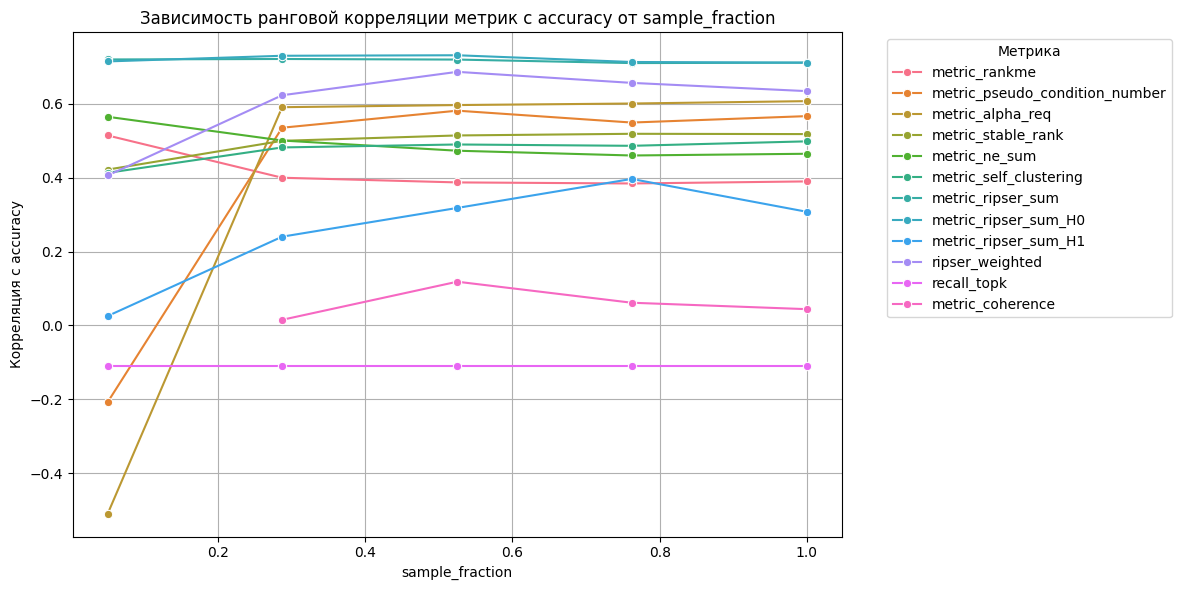

learning_rate


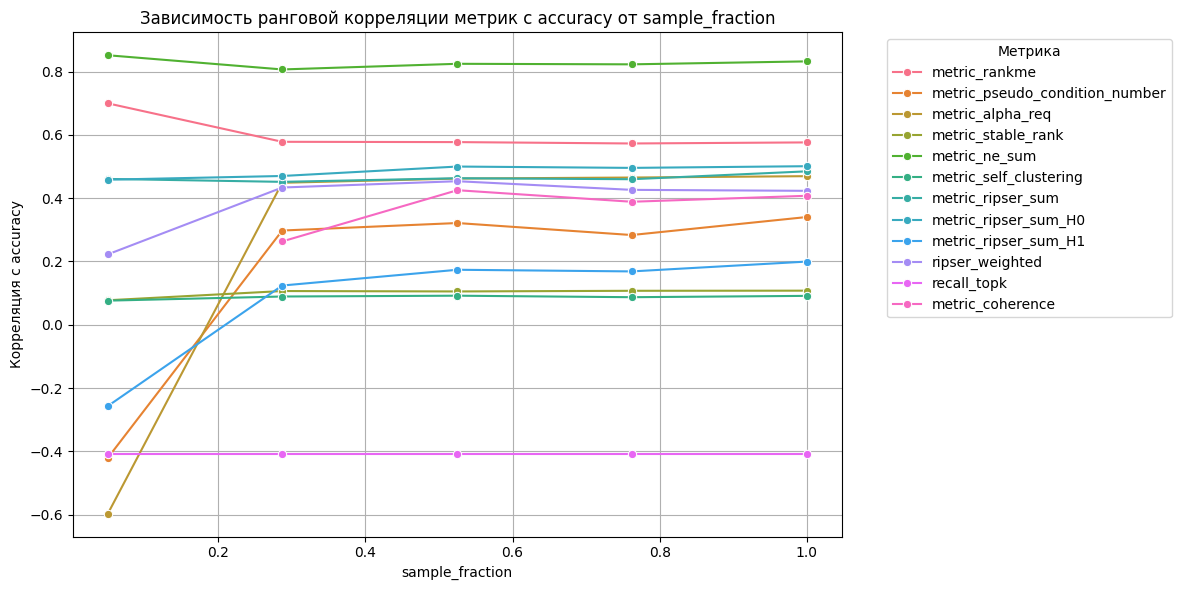

split_count


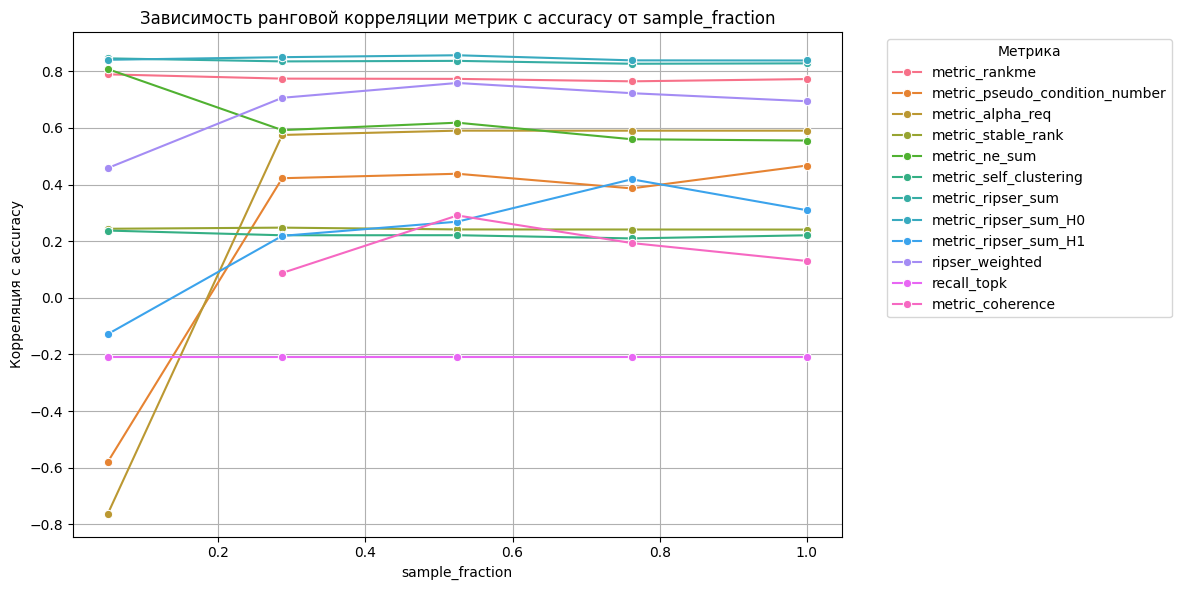

cnt_min


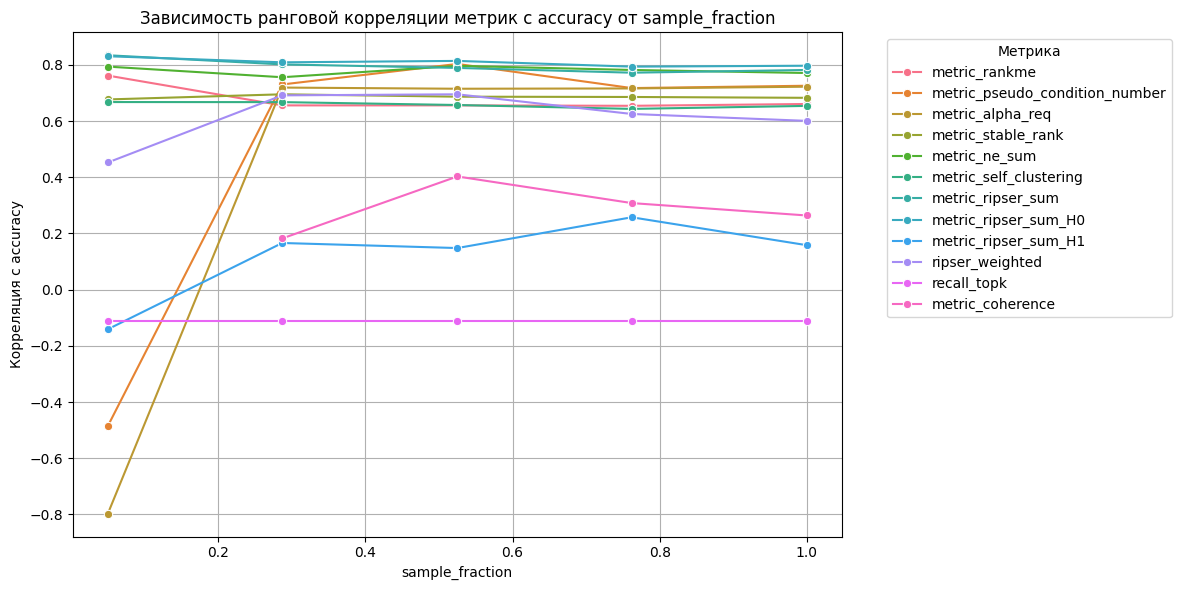

cnt_max


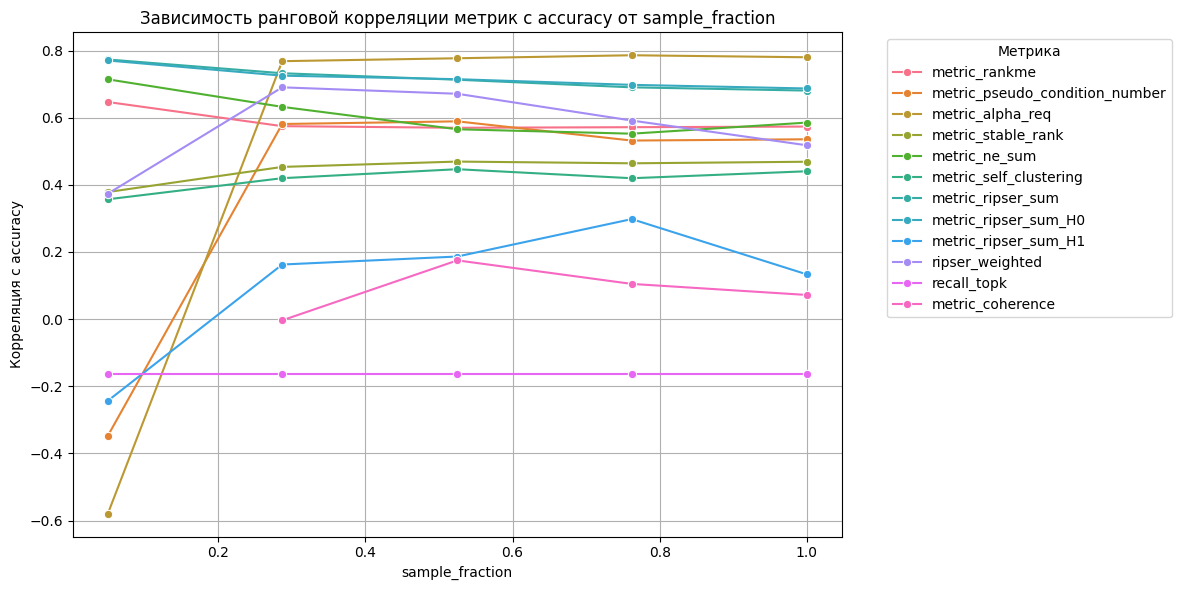

embedding_dim


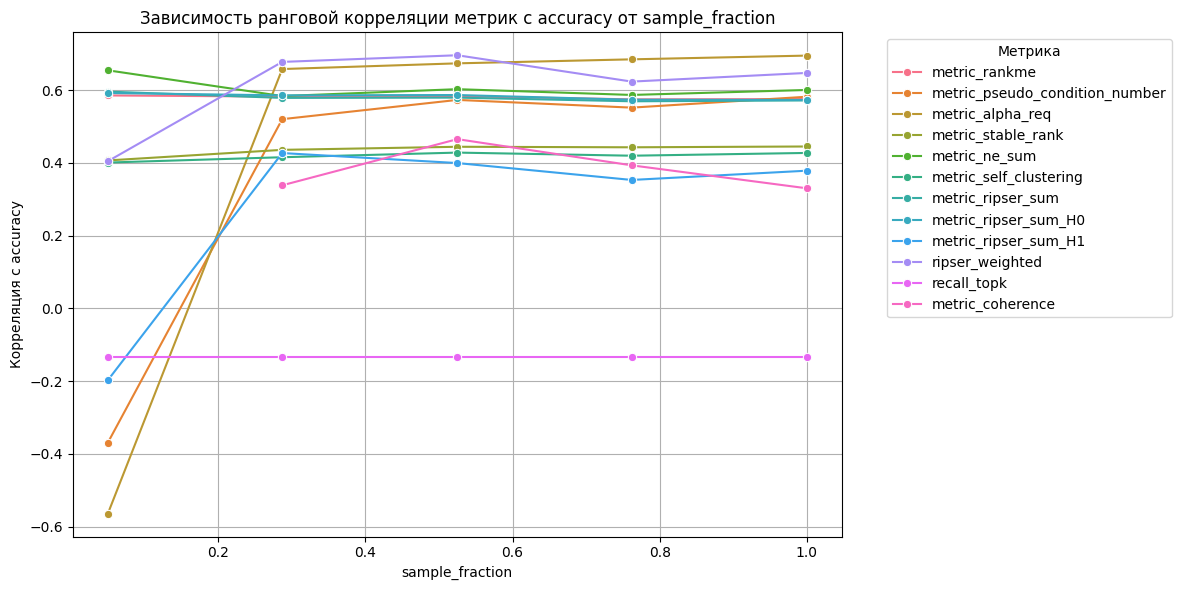

category_embedding_dim


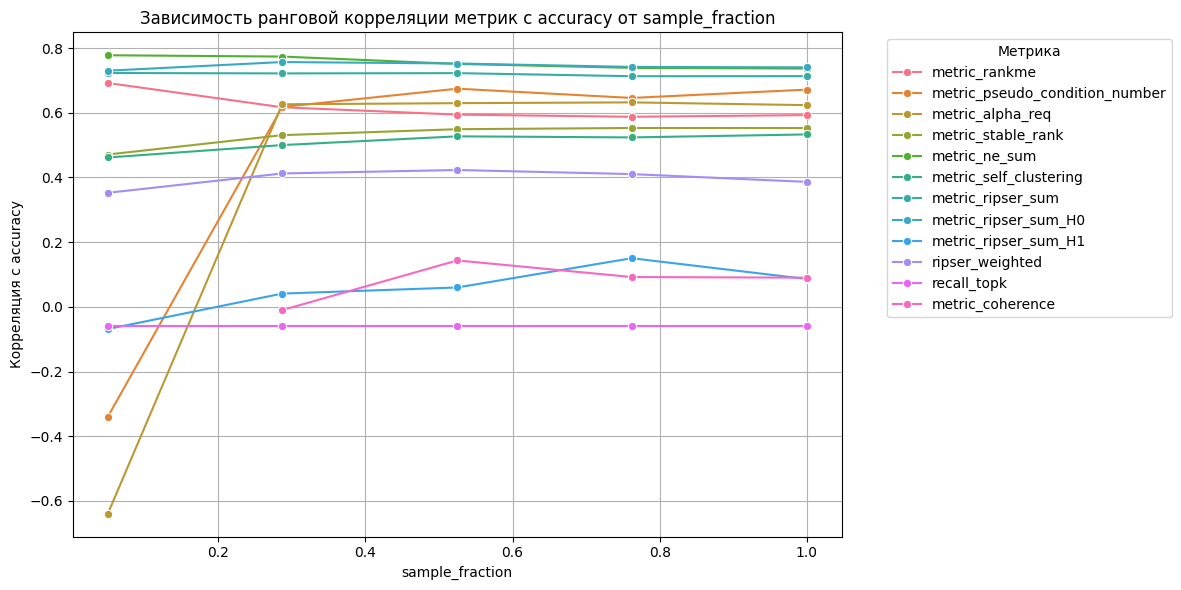

hidden_size


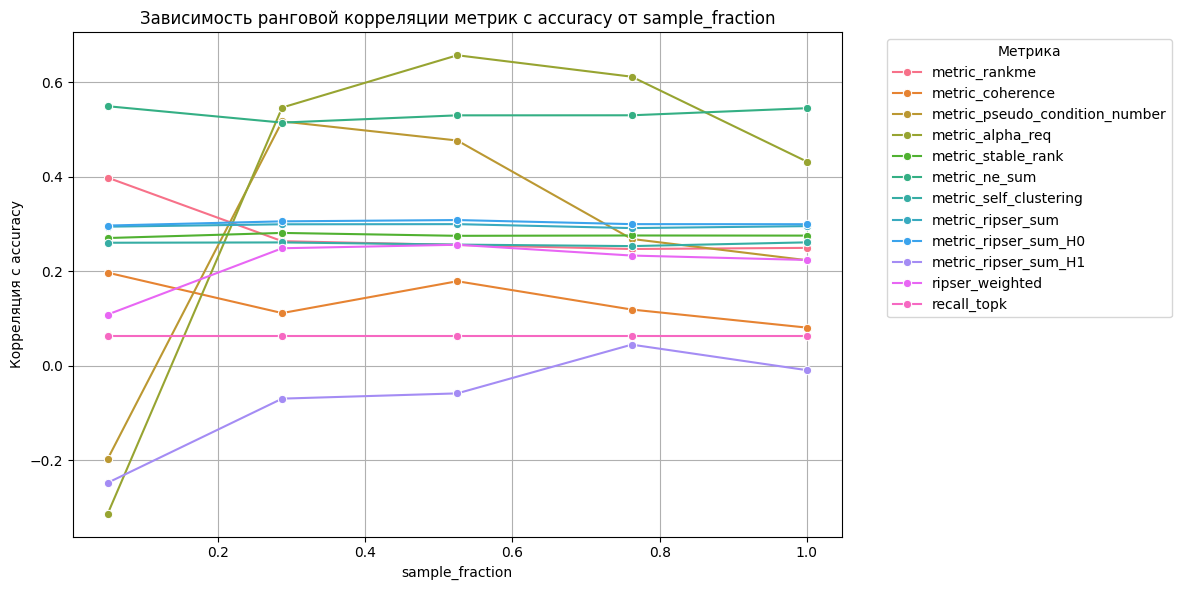

In [79]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="corr", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()

In [80]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["corr"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0              0.722362
metric_ripser_sum                 0.720648
metric_ne_sum                     0.532654
ripser_weighted                   0.514509
metric_stable_rank                0.460754
metric_rankme                     0.456961
metric_self_clustering            0.447425
metric_pseudo_condition_number    0.163793
metric_ripser_sum_H1              0.132764
metric_alpha_req                  0.040447
metric_coherence                  0.015040
recall_topk                      -0.109127
Name: corr, dtype: float64
learning_rate
metric
metric_ne_sum                     0.829472
metric_rankme                     0.639092
metric_ripser_sum_H0              0.464426
metric_ripser_sum                 0.456319
ripser_weighted                   0.328186
metric_coherence                  0.263373
metric_stable_rank                0.091971
metric_self_clustering            0.082718
metric_pseudo_condition_number   -0.061402
metric_ripser_sum_H1           

# Score of best hyperparams by metric

In [ ]:
from collections import defaultdict
params_cols=["batch_size","learning_rate",
    "split_count",
    "cnt_min",
    "cnt_max",
    "embedding_dim",
    "category_embedding_dim",
    "hidden_size"]

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data.shape[0] < 30:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    
                    pick = check_data['roc_auc'].values[
                        np.argmax(sign * check_data[metric].values)]
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "auc": pick
                    })

batch_size


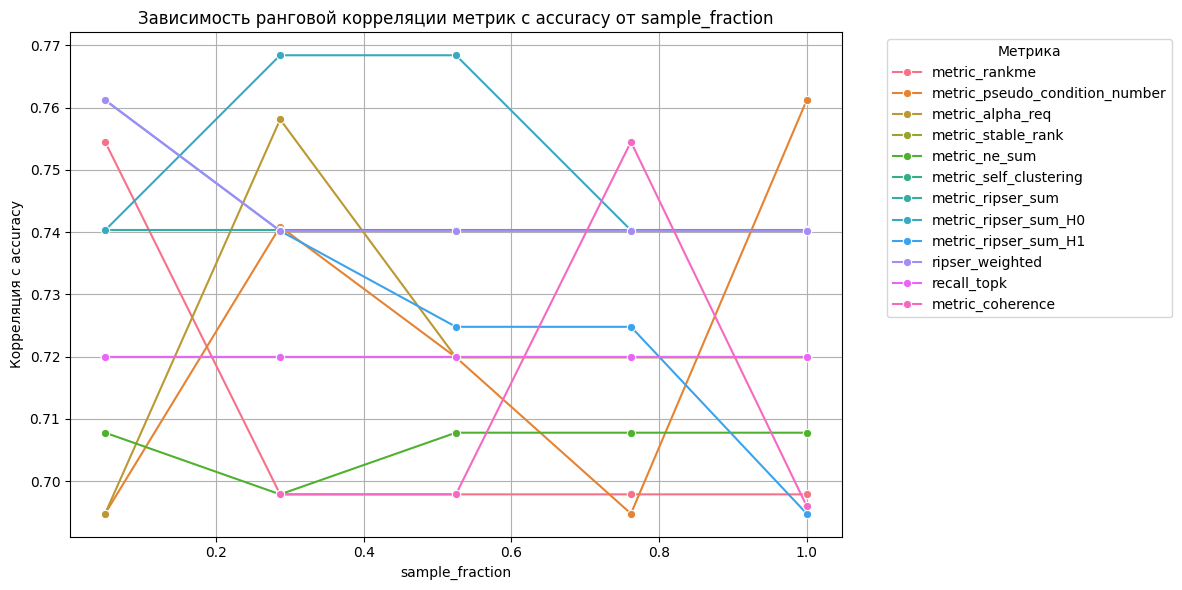

learning_rate


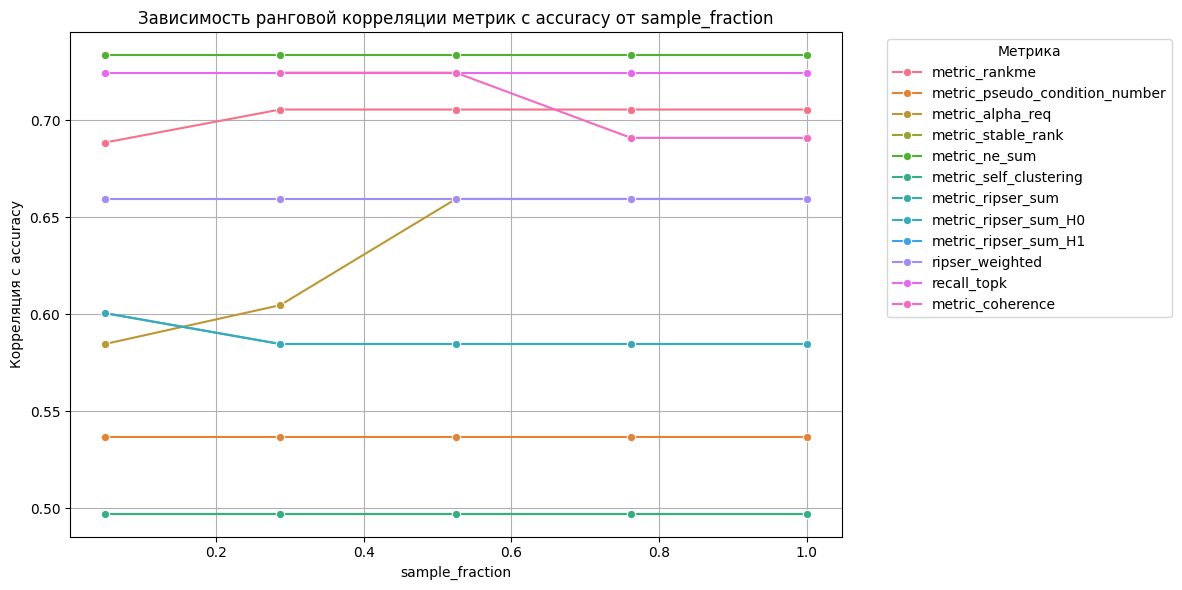

split_count


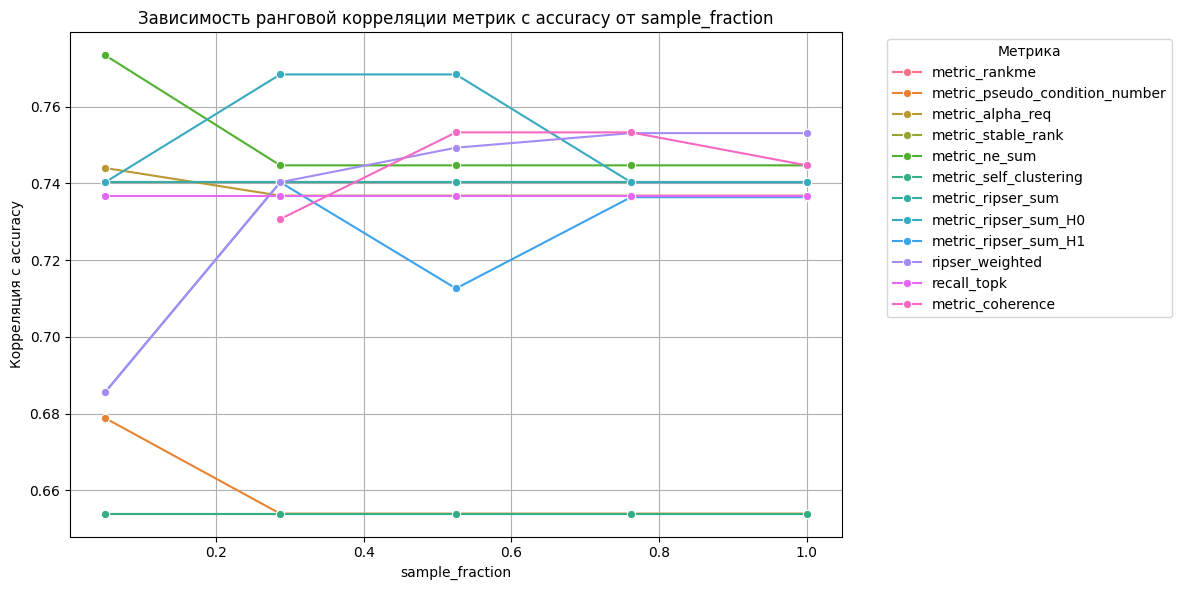

cnt_min


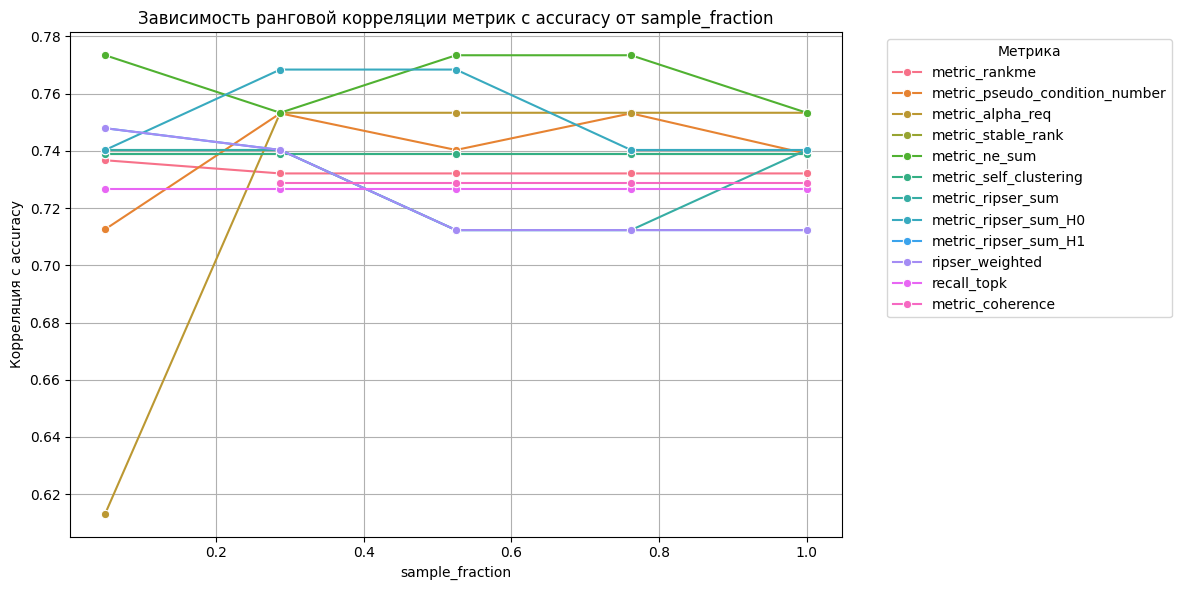

cnt_max


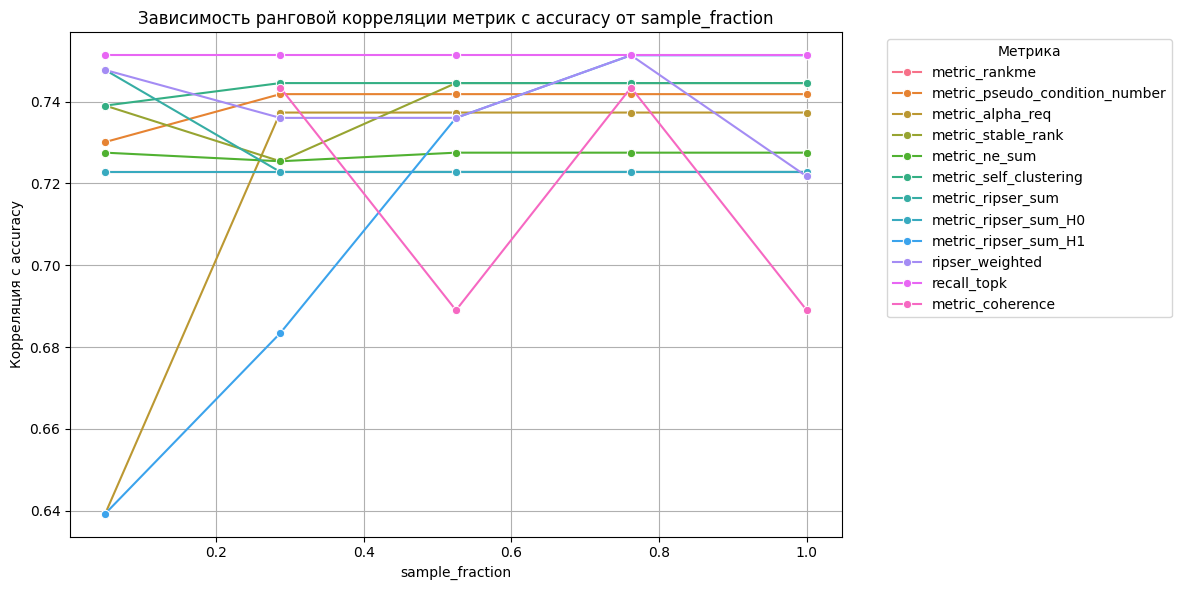

embedding_dim


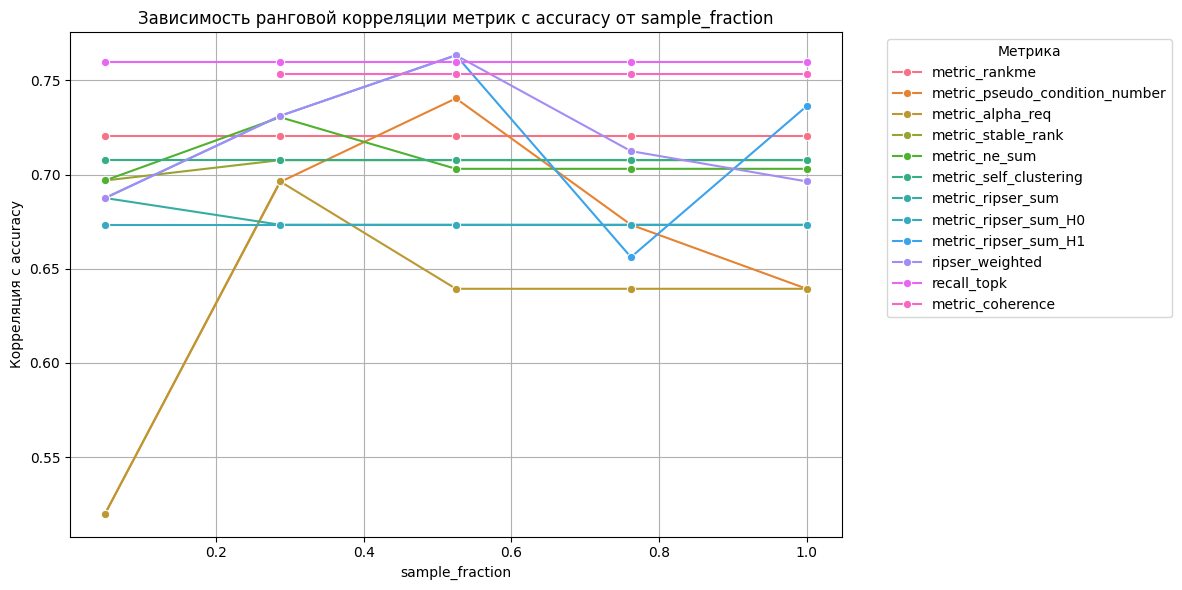

category_embedding_dim


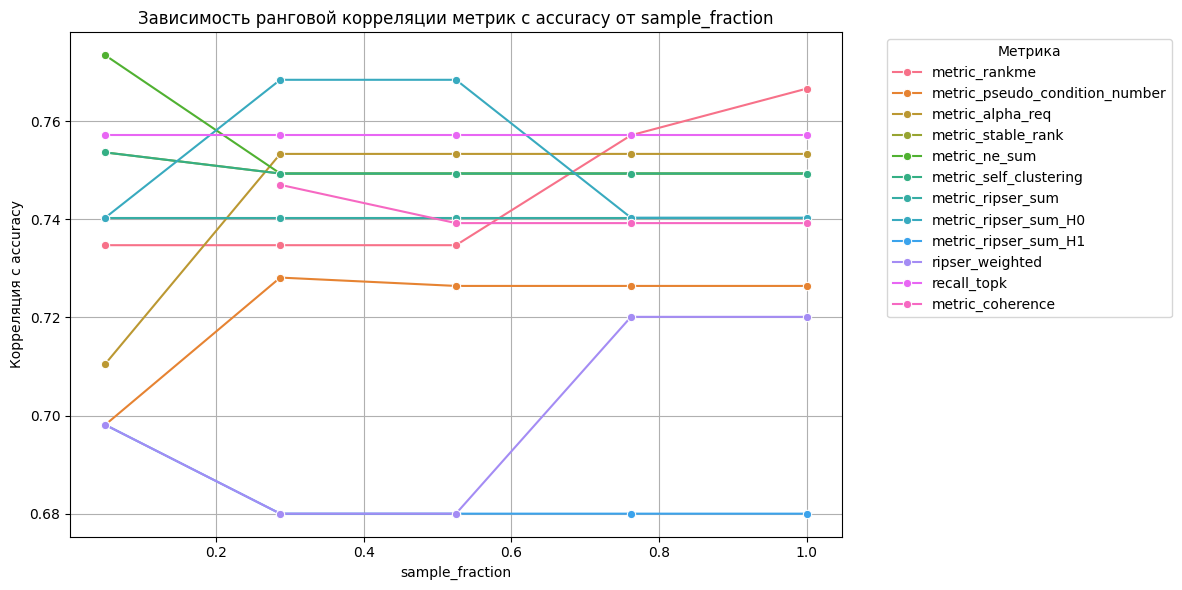

hidden_size


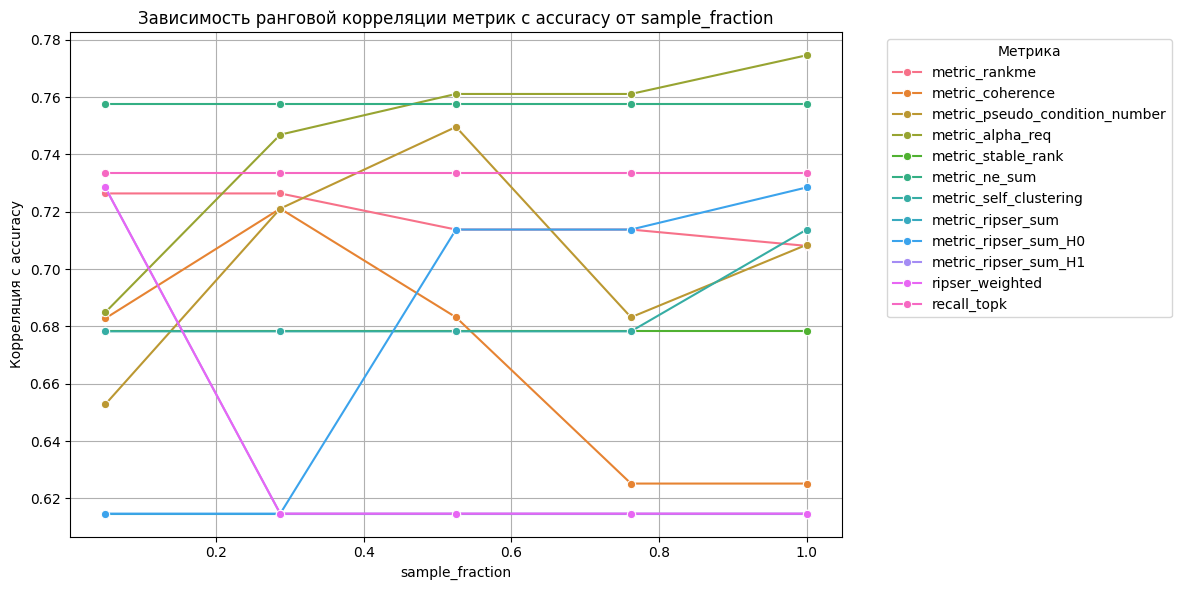

In [73]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()
    

In [77]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0              0.75435
metric_ripser_sum_H1              0.75070
ripser_weighted                   0.75070
metric_ripser_sum                 0.74030
metric_alpha_req                  0.72645
metric_rankme                     0.72620
metric_stable_rank                0.71990
metric_self_clustering            0.71990
recall_topk                       0.71990
metric_pseudo_condition_number    0.71785
metric_ne_sum                     0.70285
metric_coherence                  0.69790
Name: auc, dtype: float64
learning_rate
metric
metric_ne_sum                     0.73350
metric_coherence                  0.72450
recall_topk                       0.72450
metric_rankme                     0.69700
ripser_weighted                   0.65940
metric_ripser_sum_H1              0.65940
metric_alpha_req                  0.59460
metric_ripser_sum_H0              0.59255
metric_ripser_sum                 0.59255
metric_pseudo_condition_number    0.53640
metric_stab

In [76]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_pseudo_condition_number    0.7612
metric_ripser_sum                 0.7403
metric_ripser_sum_H0              0.7403
ripser_weighted                   0.7402
metric_stable_rank                0.7199
recall_topk                       0.7199
metric_alpha_req                  0.7199
metric_self_clustering            0.7199
metric_ne_sum                     0.7078
metric_rankme                     0.6979
metric_coherence                  0.6960
metric_ripser_sum_H1              0.6948
Name: auc, dtype: float64
learning_rate
metric
metric_ne_sum                     0.7335
recall_topk                       0.7245
metric_rankme                     0.7055
metric_coherence                  0.6909
ripser_weighted                   0.6594
metric_alpha_req                  0.6594
metric_ripser_sum_H1              0.6594
metric_ripser_sum_H0              0.5846
metric_ripser_sum                 0.5846
metric_pseudo_condition_number    0.5364
metric_stable_rank               

In [75]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0              0.751540
ripser_weighted                   0.744400
metric_ripser_sum                 0.740300
metric_ripser_sum_H1              0.729160
metric_alpha_req                  0.722520
metric_pseudo_condition_number    0.722320
metric_stable_rank                0.719900
metric_self_clustering            0.719900
recall_topk                       0.719900
metric_coherence                  0.711575
metric_rankme                     0.709220
metric_ne_sum                     0.705820
Name: auc, dtype: float64
learning_rate
metric
metric_ne_sum                     0.73350
recall_topk                       0.72450
metric_coherence                  0.70770
metric_rankme                     0.70210
ripser_weighted                   0.65940
metric_ripser_sum_H1              0.65940
metric_alpha_req                  0.63348
metric_ripser_sum_H0              0.58778
metric_ripser_sum                 0.58778
metric_pseudo_condition_number    0.53640

In [74]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0              0.751540
ripser_weighted                   0.744400
metric_ripser_sum                 0.740300
metric_ripser_sum_H1              0.729160
metric_alpha_req                  0.722520
metric_pseudo_condition_number    0.722320
metric_stable_rank                0.719900
metric_self_clustering            0.719900
recall_topk                       0.719900
metric_coherence                  0.711575
metric_rankme                     0.709220
metric_ne_sum                     0.705820
Name: auc, dtype: float64
learning_rate
metric
metric_ne_sum                     0.73350
recall_topk                       0.72450
metric_coherence                  0.70770
metric_rankme                     0.70210
ripser_weighted                   0.65940
metric_ripser_sum_H1              0.65940
metric_alpha_req                  0.63348
metric_ripser_sum_H0              0.58778
metric_ripser_sum                 0.58778
metric_pseudo_condition_number    0.53640

/tmp/ipykernel_3643076/655376316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_corr.values, y=mean_corr.index, palette="viridis")
/tmp/ipykernel_3643076/655376316.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


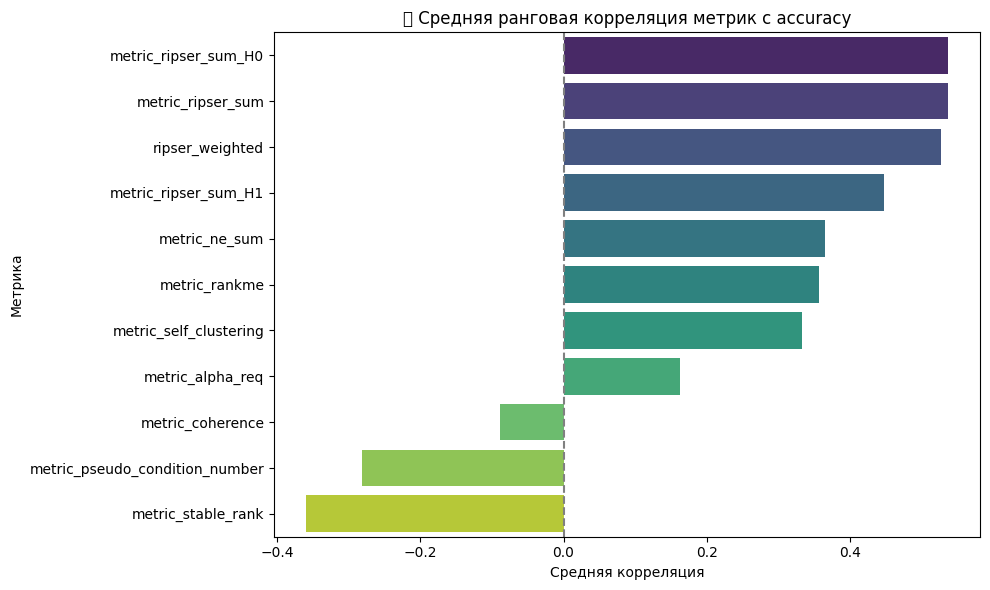

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x=mean_corr.values, y=mean_corr.index, palette="viridis")
plt.title("📊 Средняя ранговая корреляция метрик с accuracy")
plt.xlabel("Средняя корреляция")
plt.ylabel("Метрика")
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

In [61]:
std_corr = spear_corr_df.groupby("metric")["correlation"].std().sort_values()

/tmp/ipykernel_3302613/2625709754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3302613/2625709754.py:10: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


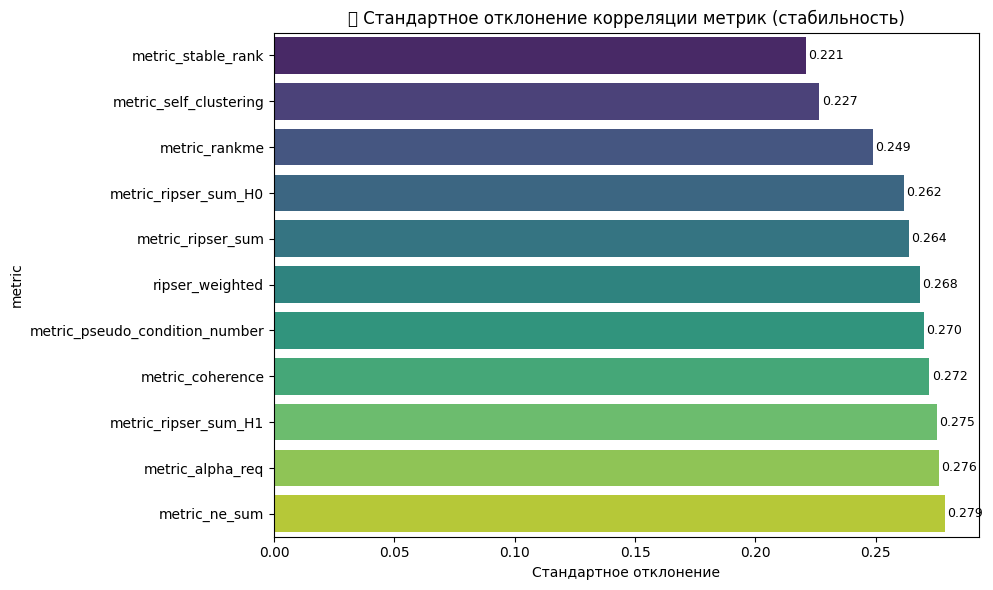

In [62]:
sorted_std = std_corr.sort_values(ascending=True)
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")

for i, v in enumerate(sorted_std.values):
    plt.text(v + 0.001, i, f"{v:.3f}", color='black', ha='left', va='center', fontsize=9)

plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
plt.xlabel("Стандартное отклонение")
plt.tight_layout()
plt.show()

In [63]:
from scipy.stats import spearmanr

trend_corr = (
    corr_df.groupby("metric")
    .apply(lambda df: spearmanr(df["sample_fraction"], df["correlation"]).correlation)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=trend_corr.values, y=trend_corr.index, palette="magma")
plt.title("📈 Тренд влияния sample_fraction на корреляцию")
plt.xlabel("Коэффициент Спирмена (sample_fraction ↔ correlation)")
plt.ylabel("Метрика")
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()


KeyError: 'correlation'

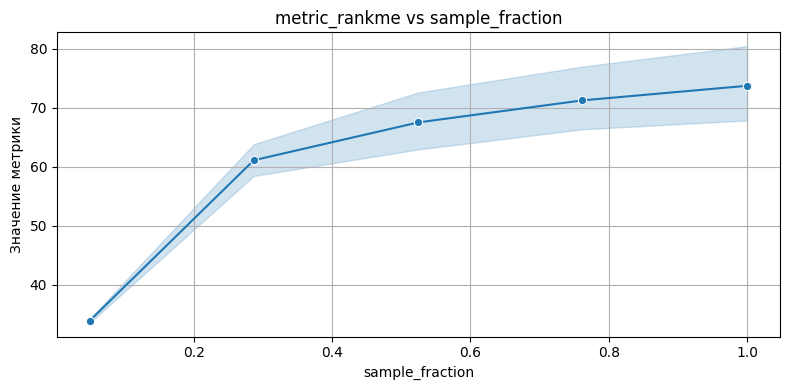

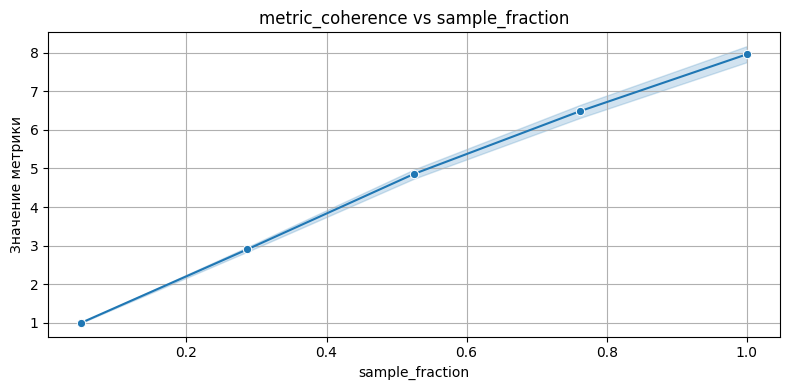

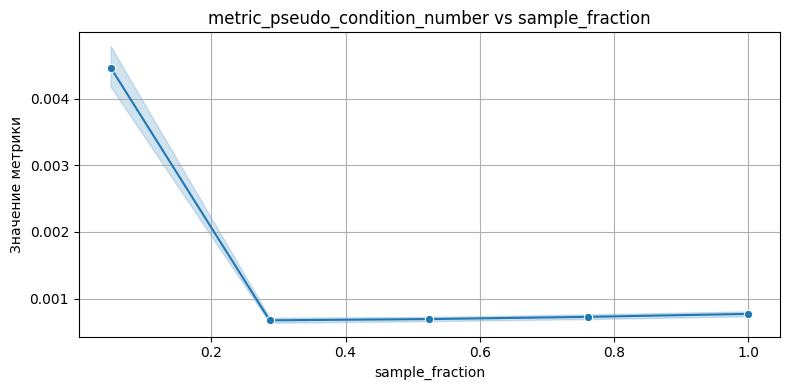

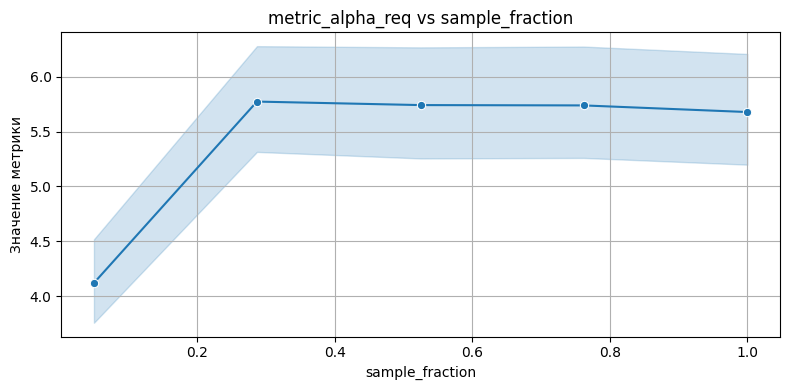

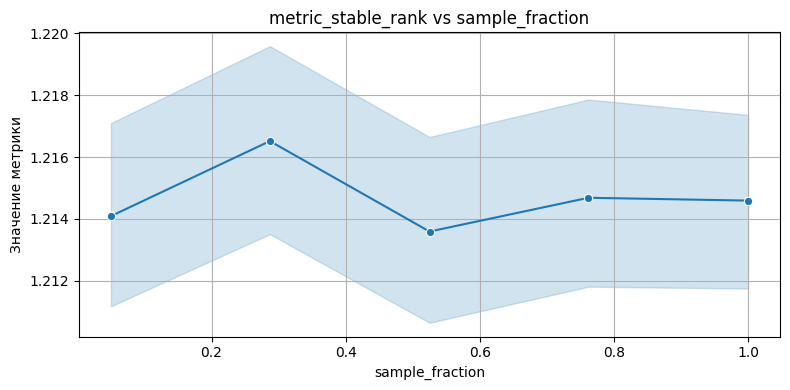

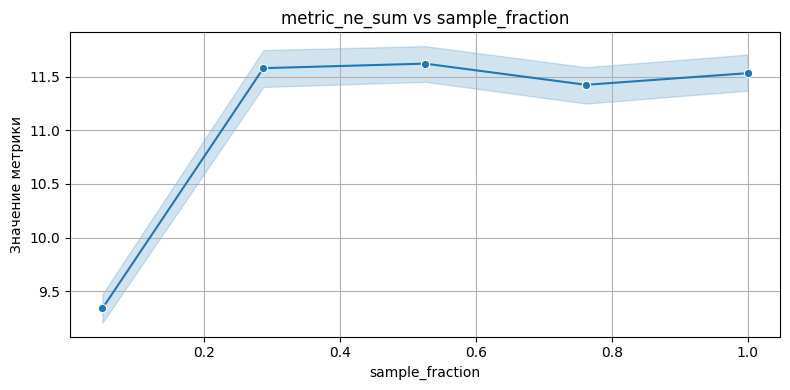

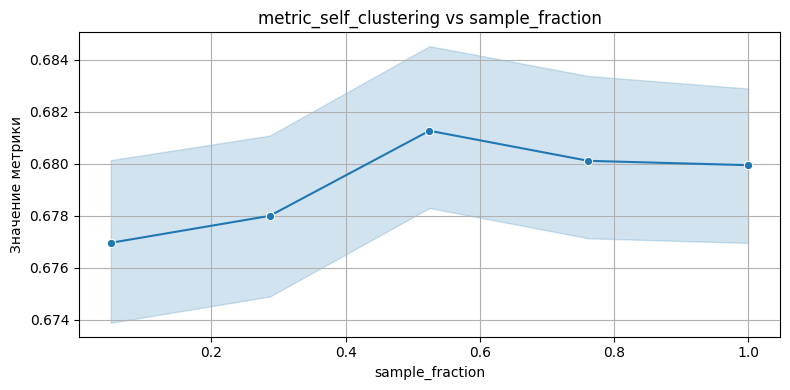

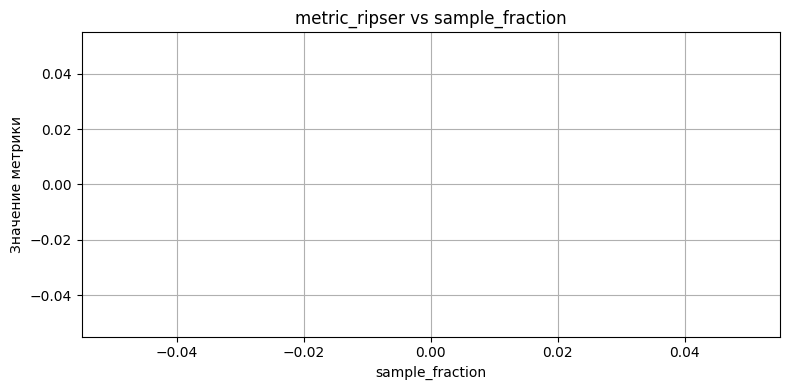

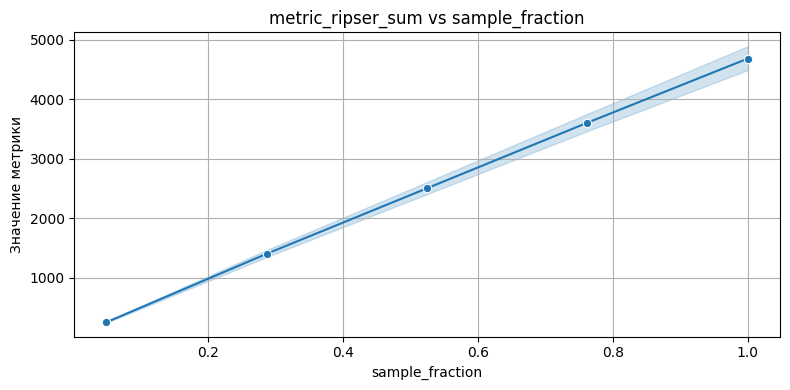

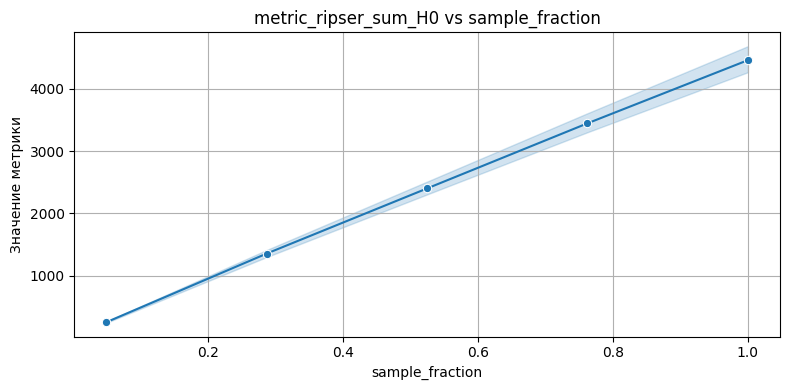

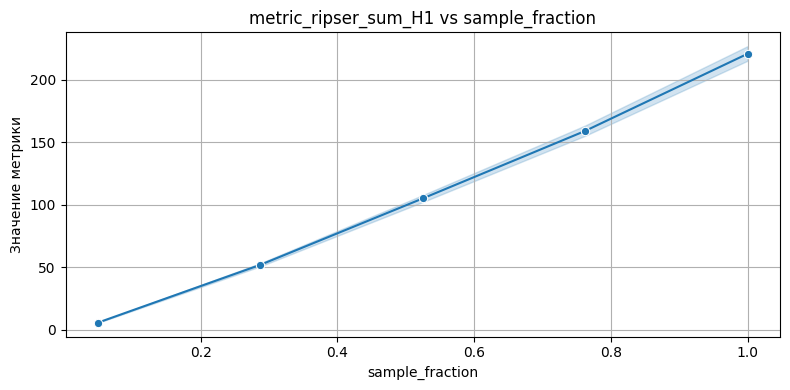

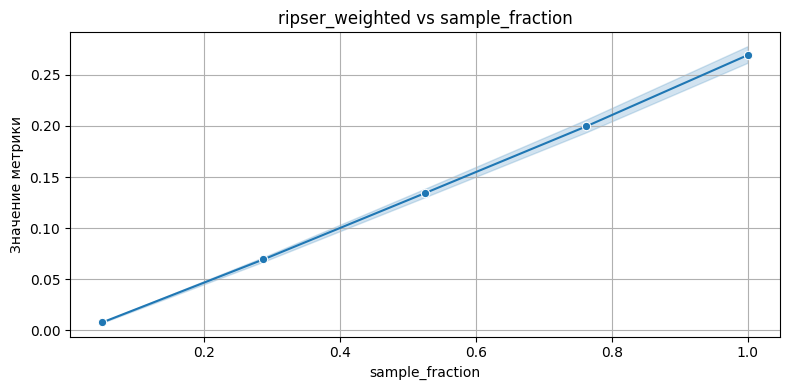

In [64]:
for metric in metric_columns:
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=df_all, x="sample_fraction", y=metric, marker="o")
    plt.title(f"{metric} vs sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Значение метрики")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [1]:
from collections import defaultdict

def count_paths(start, end, allowed_ops):
    dp = defaultdict(int)
    dp[start] = 1

    for x in range(start, end + 1):
        if 'A' in allowed_ops and x + 3 <= end:
            dp[x + 3] += dp[x]
        if 'B' in allowed_ops and x * 4 <= end:
            dp[x * 4] += dp[x]
        if 'C' in allowed_ops and x * 5 <= end:
            dp[x * 5] += dp[x]
    return dp[end]

# 1 → 362: без B (только A и C)
paths_1_to_362 = count_paths(1, 362, allowed_ops={'A', 'C'})

# 362 → 725: все команды разрешены
paths_362_to_725 = count_paths(362, 725, allowed_ops={'A', 'B', 'C'})

# Общее число программ
total_programs = paths_1_to_362 * paths_362_to_725

print("Ответ:", total_programs)


Ответ: 58
